=== KET QUA HUAN LUYEN ===
So epoch da chay: 10000
Thoi gian huan luyen: 0.043217 giay
Loss cuoi cung: 0.0001356096
Chua dat target_loss = 0.0001 sau 10000 epoch

=== TRONG SO CUOI CUNG ===
W11 = 0.200000, W21 = 0.190003, b1 = 0.890003
W12 = -0.500000, W22 = 0.171250, b2 = -0.128750
w1  = 1.706228, w2  = 0.665183, b  = 2.476392

Du doan cuoi cung y_hat = 0.983532


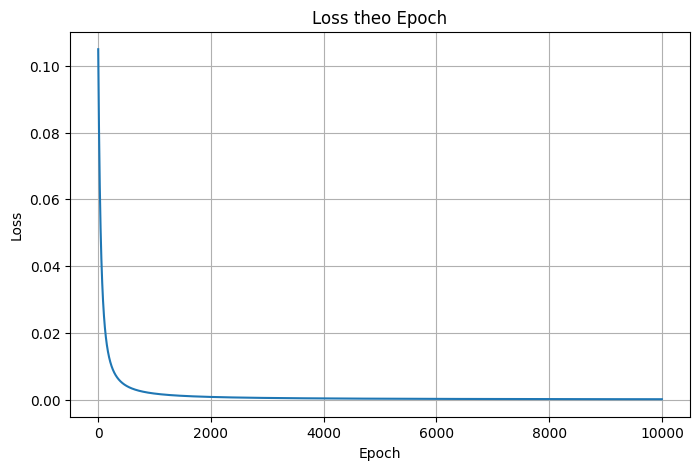

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative_from_output(s):
    # s đã là sigmoid(x)
    return s * (1 - s)

x1 = 0
x2 = 1
y = 1

X = np.array([x1, x2], dtype=float)
y_true = float(y)


W11 = 0.2
W21 = -0.3
b1  = 0.4

W12 = -0.5
W22 = 0.1
b2  = -0.2

w1 = 0.3
w2 = -0.4
b  = 0.2

learning_rate = 0.1
max_epochs = 10000
target_loss = 1e-4   

loss_history = []

start_time = time.time()
converged_epoch = None

for epoch in range(max_epochs):
    # ===== Forward =====
    z1 = W11 * X[0] + W21 * X[1] + b1
    h1 = sigmoid(z1)

    z2 = W12 * X[0] + W22 * X[1] + b2
    h2 = sigmoid(z2)

    zo = w1 * h1 + w2 * h2 + b
    y_hat = sigmoid(zo)

    loss = 0.5 * (y_true - y_hat) ** 2
    loss_history.append(loss)


    if loss < target_loss:
        converged_epoch = epoch + 1
        break

    delta_o = (y_hat - y_true) * sigmoid_derivative_from_output(y_hat)

    grad_w1 = delta_o * h1
    grad_w2 = delta_o * h2
    grad_b  = delta_o

    delta_1 = sigmoid_derivative_from_output(h1) * w1 * delta_o
    delta_2 = sigmoid_derivative_from_output(h2) * w2 * delta_o

    grad_W11 = delta_1 * X[0]
    grad_W21 = delta_1 * X[1]
    grad_b1  = delta_1

    grad_W12 = delta_2 * X[0]
    grad_W22 = delta_2 * X[1]
    grad_b2  = delta_2

    w1 -= learning_rate * grad_w1
    w2 -= learning_rate * grad_w2
    b  -= learning_rate * grad_b

    W11 -= learning_rate * grad_W11
    W21 -= learning_rate * grad_W21
    b1  -= learning_rate * grad_b1

    W12 -= learning_rate * grad_W12
    W22 -= learning_rate * grad_W22
    b2  -= learning_rate * grad_b2

end_time = time.time()
training_time = end_time - start_time

print("=== KET QUA HUAN LUYEN ===")
print(f"So epoch da chay: {len(loss_history)}")
print(f"Thoi gian huan luyen: {training_time:.6f} giay")
print(f"Loss cuoi cung: {loss_history[-1]:.10f}")

if converged_epoch is not None:
    print(f"Dat target_loss = {target_loss} tai epoch: {converged_epoch}")
else:
    print(f"Chua dat target_loss = {target_loss} sau {max_epochs} epoch")

print("\n=== TRONG SO CUOI CUNG ===")
print(f"W11 = {W11:.6f}, W21 = {W21:.6f}, b1 = {b1:.6f}")
print(f"W12 = {W12:.6f}, W22 = {W22:.6f}, b2 = {b2:.6f}")
print(f"w1  = {w1:.6f}, w2  = {w2:.6f}, b  = {b:.6f}")

z1 = W11 * X[0] + W21 * X[1] + b1
h1 = sigmoid(z1)

z2 = W12 * X[0] + W22 * X[1] + b2
h2 = sigmoid(z2)

zo = w1 * h1 + w2 * h2 + b
y_hat = sigmoid(zo)

print(f"\nDu doan cuoi cung y_hat = {y_hat:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss theo Epoch")
plt.grid(True)
plt.show()